<a href="https://colab.research.google.com/github/yentran31251022363-ship-it/nhandienmat/blob/main/nhan_dien_mat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# ── Cài & import ──────────────────────────────────────────────
import os, glob, zipfile
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

# ================================================================
#  SỬA ĐƯỜNG DẪN NÀY cho đúng với file ZIP chứa data mặt trên Drive
# ================================================================
ZIP_PATH = '/content/drive/MyDrive/zip/60 tấm selfies - sáng T2-20260529T014948Z-3-001.zip' # <-- SỬA TÊN FILE ZIP Ở ĐÂY
# ================================================================

EXTRACT_DIR = '/content/data'
os.makedirs(EXTRACT_DIR, exist_ok=True)

if os.path.exists(ZIP_PATH):
    print(f'📦 Đang giải nén ...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)
    print('✅ Xong! Cấu trúc thư mục:')
    for root, dirs, files in os.walk(EXTRACT_DIR):
        depth = root.replace(EXTRACT_DIR, '').count(os.sep)
        if depth <= 2:
            indent = '  ' * depth
            print(f'{indent}{os.path.basename(root)}/')
else:
    print(f'❌ Không thấy file: {ZIP_PATH}')
    print('   → Kiểm tra lại tên file và đường dẫn trên Drive')

TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
📦 Đang giải nén ...
✅ Xong! Cấu trúc thư mục:
data/
  60 tấm selfies - sáng T2/
    Đinh Hữu Khánh Anh/
    Phạm Nguyễn Bảo Châu /
    Phạm Phú Hoà/
    Nguyễn Thị Ngọc Tuyết/
    Nguyễn Đặng Vinh Phúc/
    Nguyễn Việt Đức/
    Đỗ An Phúc/
    Đoàn Hùng/
    Lê Quang Dũng/
    Trần Hải Yến/
    Nguyễn Hoàng Quế Châu /
    Ngô Quốc Trung/
    Nguyễn Tiến Mạnh/
    Lê Tuấn Thành/
    Vũ Quang Thái/
    Nguyen Ngoc Bao/
    Phạm Hứa Nhật Minh /
    Lương Ngọc Thuận/
    Nguyễn Thị Khánh Lê/
    HoangKyAnh/
    Nguyễn Phạm Hoàng An/
    Phạm Gia Thành Duy /


In [ ]:
# Tự động tìm thư mục chứa các class ảnh
def find_dataset_root(base='/content/data'):
    best_dir, best_n = base, 0
    for root, dirs, files in os.walk(base):
        imgs = [f for f in files if f.lower().endswith(('.jpg','.jpeg','.png'))]
        subdirs = [d for d in dirs if os.path.isdir(os.path.join(root, d))]
        if len(subdirs) > best_n:
            best_dir, best_n = root, len(subdirs)
    return best_dir

DATA_DIR = find_dataset_root()
classes  = sorted([c for c in os.listdir(DATA_DIR)
                   if os.path.isdir(os.path.join(DATA_DIR, c))])

print(f'📂 Data root  : {DATA_DIR}')
print(f'✅ {len(classes)} người : {classes}')

counts = {}
for c in classes:
    imgs = [p for p in glob.glob(os.path.join(DATA_DIR, c, '*'))
            if p.lower().endswith(('.jpg','.jpeg','.png'))]
    counts[c] = len(imgs)

for k,v in counts.items():
    print(f'  {k:>10}: {v} ảnh')
print(f'\nTổng: {sum(counts.values())} ảnh')

📂 Data root  : /content/data/60 tấm selfies - sáng T2
✅ 22 người : ['HoangKyAnh', 'Lê Quang Dũng', 'Lê Tuấn Thành', 'Lương Ngọc Thuận', 'Nguyen Ngoc Bao', 'Nguyễn Hoàng Quế Châu ', 'Nguyễn Phạm Hoàng An', 'Nguyễn Thị Khánh Lê', 'Nguyễn Thị Ngọc Tuyết', 'Nguyễn Tiến Mạnh', 'Nguyễn Việt Đức', 'Nguyễn Đặng Vinh Phúc', 'Ngô Quốc Trung', 'Phạm Gia Thành Duy ', 'Phạm Hứa Nhật Minh ', 'Phạm Nguyễn Bảo Châu ', 'Phạm Phú Hoà', 'Trần Hải Yến', 'Vũ Quang Thái', 'Đinh Hữu Khánh Anh', 'Đoàn Hùng', 'Đỗ An Phúc']
  HoangKyAnh: 64 ảnh
  Lê Quang Dũng: 60 ảnh
  Lê Tuấn Thành: 60 ảnh
  Lương Ngọc Thuận: 60 ảnh
  Nguyen Ngoc Bao: 60 ảnh
  Nguyễn Hoàng Quế Châu : 60 ảnh
  Nguyễn Phạm Hoàng An: 60 ảnh
  Nguyễn Thị Khánh Lê: 0 ảnh
  Nguyễn Thị Ngọc Tuyết: 0 ảnh
  Nguyễn Tiến Mạnh: 60 ảnh
  Nguyễn Việt Đức: 60 ảnh
  Nguyễn Đặng Vinh Phúc: 60 ảnh
  Ngô Quốc Trung: 0 ảnh
  Phạm Gia Thành Duy : 60 ảnh
  Phạm Hứa Nhật Minh : 60 ảnh
  Phạm Nguyễn Bảo Châu : 65 ảnh
  Phạm Phú Hoà: 60 ảnh
  Trần Hải Yến: 60 ảnh
  V

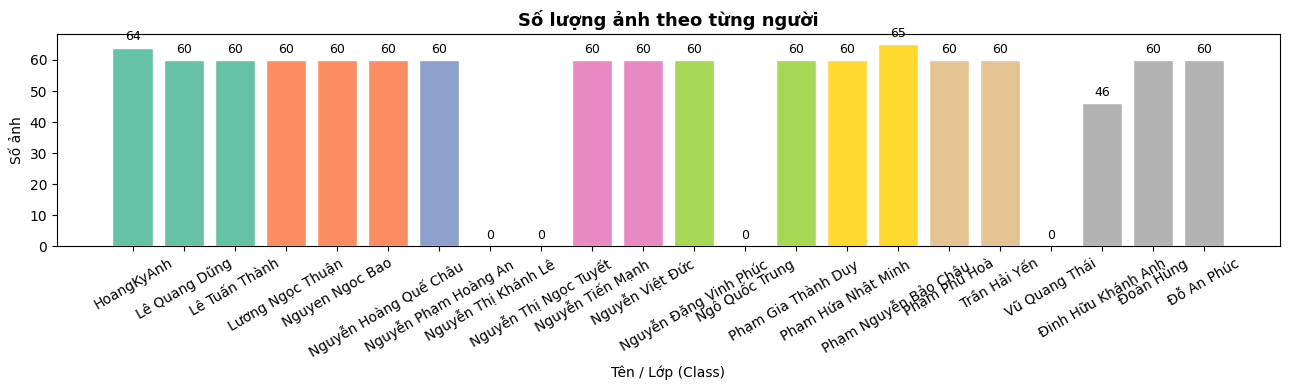

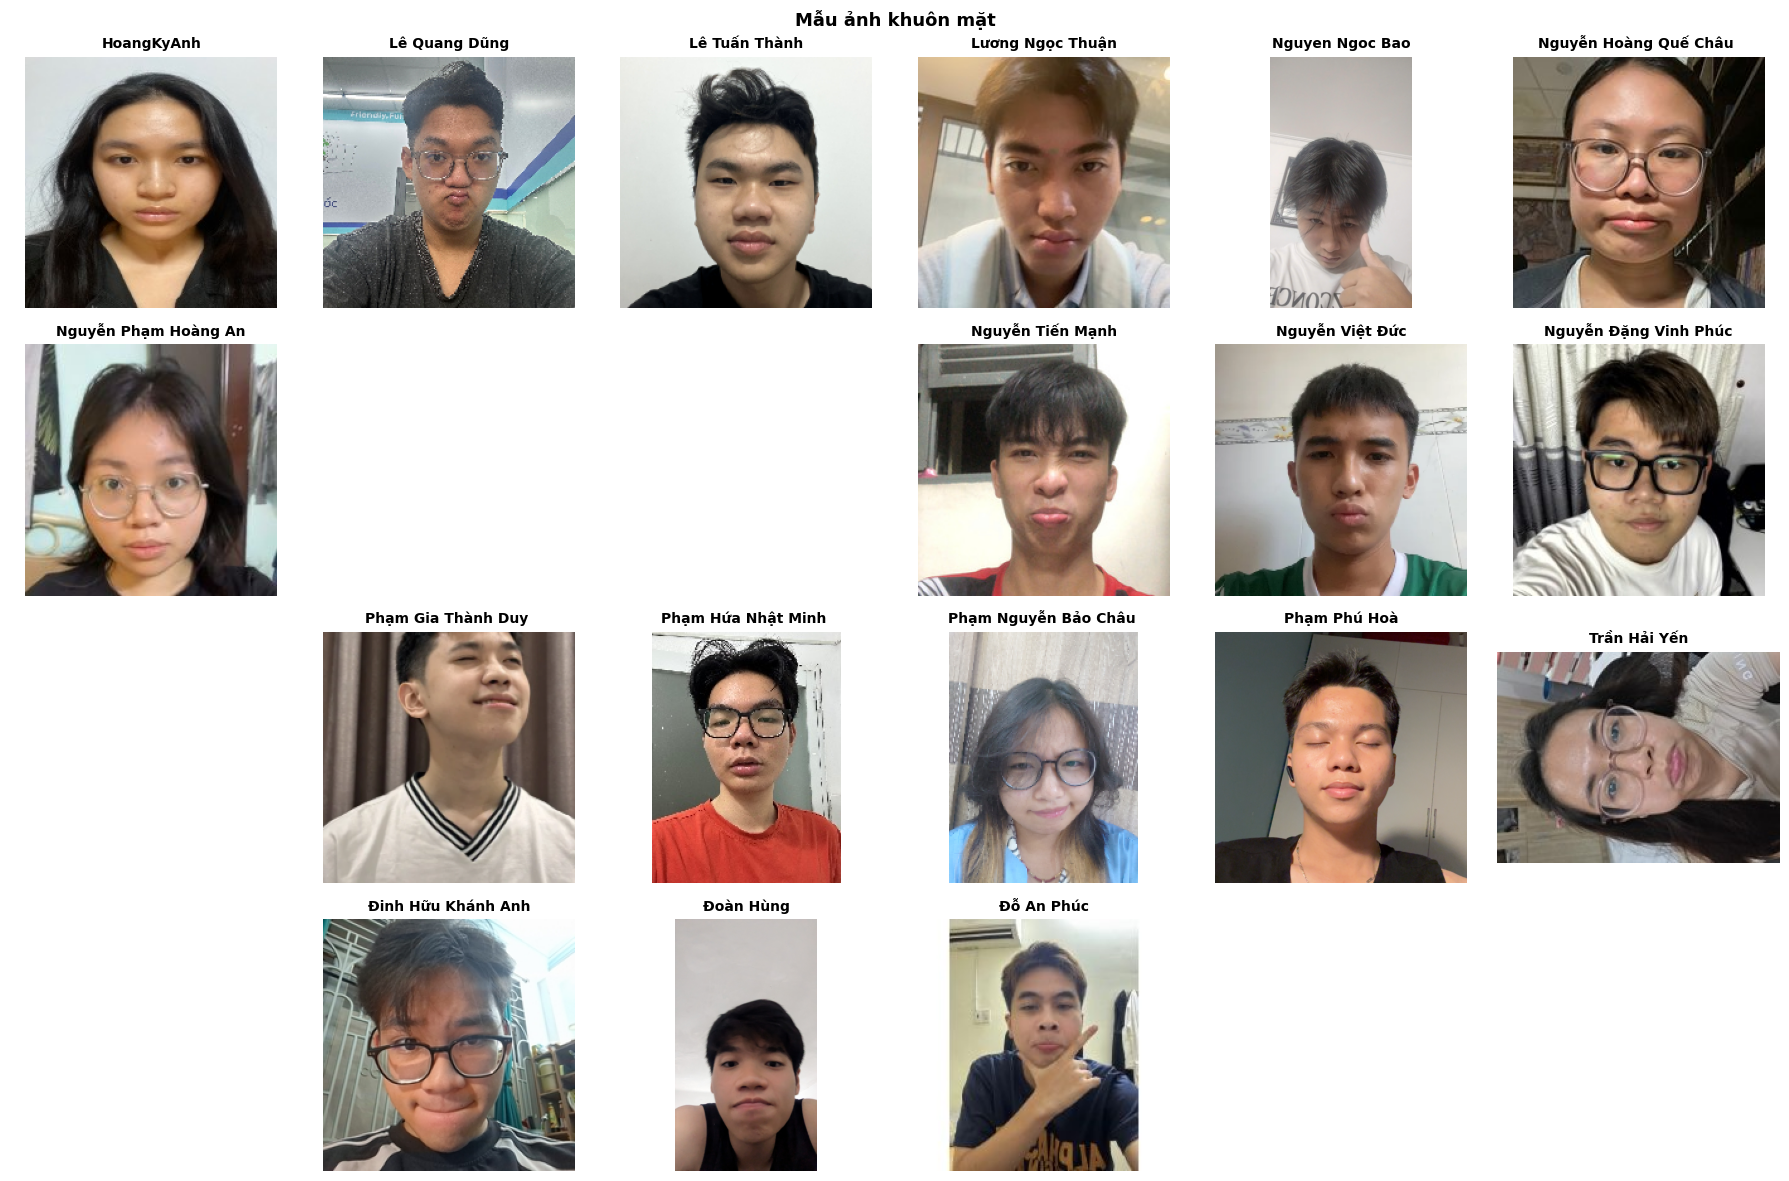

Found 988 images belonging to 22 classes.
Found 245 images belonging to 22 classes.
Train: 988 ảnh | Val: 245 ảnh


In [ ]:
# Biểu đồ số lượng ảnh
fig, ax = plt.subplots(figsize=(13,4))
bars = ax.bar(counts.keys(), counts.values(),
              color=plt.cm.Set2(np.linspace(0,1,len(classes))), edgecolor='white')
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title('Số lượng ảnh theo từng người', fontsize=13, fontweight='bold')
ax.set_xlabel('Tên / Lớp (Class)'); ax.set_ylabel('Số ảnh')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

# Mẫu ảnh mỗi class
cols = 6; rows = (len(classes) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
axes = axes.flatten()
for i, cls in enumerate(classes):
    imgs = [p for p in glob.glob(os.path.join(DATA_DIR, cls, '*'))
            if p.lower().endswith(('.jpg','.jpeg','.png'))]
    if imgs:
        axes[i].imshow(Image.open(np.random.choice(imgs)).convert('RGB'))
        axes[i].set_title(f'{cls}', fontsize=10, fontweight='bold')
    axes[i].axis('off')
for j in range(len(classes), len(axes)): axes[j].axis('off')
plt.suptitle('Mẫu ảnh khuôn mặt', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

IMG_SIZE    = (128, 128) # Có thể tăng lên (160, 160) hoặc (224, 224) nếu ảnh mặt chi tiết
BATCH_SIZE  = 32
SEED        = 42
NUM_CLASSES = len(classes)

train_gen = ImageDataGenerator(
    rescale=1./255, validation_split=0.2,
    rotation_range=15, width_shift_range=0.1, height_shift_range=0.1,
    shear_range=0.1, zoom_range=0.15, horizontal_flip=True,
    brightness_range=[0.8, 1.2], fill_mode='nearest'
).flow_from_directory(DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=SEED, shuffle=True)

val_gen = ImageDataGenerator(rescale=1./255, validation_split=0.2
).flow_from_directory(DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=SEED, shuffle=False)

class_names = list(train_gen.class_indices.keys())
print(f'Train: {train_gen.samples} ảnh | Val: {val_gen.samples} ảnh')

def build_custom_cnn(input_shape, num_classes):
    return models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32,(3,3),padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.Conv2D(32,(3,3),padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.MaxPooling2D(2,2), layers.Dropout(0.25),
        layers.Conv2D(64,(3,3),padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.Conv2D(64,(3,3),padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.MaxPooling2D(2,2), layers.Dropout(0.25),
        layers.Conv2D(128,(3,3),padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.Conv2D(128,(3,3),padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.MaxPooling2D(2,2), layers.Dropout(0.30),
        layers.Conv2D(256,(3,3),padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.GlobalAveragePooling2D(), layers.Dropout(0.40),
        layers.Dense(512, activation='relu'), layers.BatchNormalization(), layers.Dropout(0.50),
        layers.Dense(num_classes, activation='softmax')
    ], name='CustomCNN')

def build_mobilenetv2(input_shape, num_classes):
    base = keras.applications.MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    base.trainable = False
    inp = keras.Input(shape=input_shape)
    x   = keras.applications.mobilenet_v2.preprocess_input(inp * 255.0)
    x   = base(x, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(256, activation='relu')(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dropout(0.4)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inp, out, name='MobileNetV2_Transfer'), base

In [ ]:
# ── Chọn mô hình ──────────────────────────────────────
ACTIVE_MODEL = 'mobile'   # 'mobile' hoặc 'cnn'
# ──────────────────────────────────────────────────────
if ACTIVE_MODEL == 'mobile':
    model, base_model = build_mobilenetv2((*IMG_SIZE,3), NUM_CLASSES)
else:
    model = build_custom_cnn((*IMG_SIZE,3), NUM_CLASSES)
    base_model = None

model.summary()

model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='categorical_crossentropy', metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint('/content/best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

print('── Phase 1: Train classifier head (base frozen) ──')
history1 = model.fit(train_gen, epochs=35, validation_data=val_gen, callbacks=callbacks, verbose=1)

# Phase 2: Fine-tuning (MobileNetV2)
if ACTIVE_MODEL == 'mobile' and base_model is not None:
    print('\n── Phase 2: Fine-tune 30 layer cuối ──')
    base_model.trainable = True
    for layer in base_model.layers[:-30]:
        layer.trainable = False
    model.compile(optimizer=keras.optimizers.Adam(1e-4),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    history2 = model.fit(train_gen, epochs=20, validation_data=val_gen, callbacks=callbacks, verbose=1)
    for k in history1.history:
        history1.history[k] += history2.history.get(k, [])

final_history = history1
print('✅ Training hoàn tất!')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 22)             │         5,654 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,592,598 (9.89 MB)

 Trainable params: 334,102 (1.27 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

── Phase 1: Train classifier head (base frozen) ──
Epoch 1/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 986ms/step - accuracy: 0.4628 - loss: 2.1626
Epoch 1: val_accuracy improved from None to 0.86122, saving model to /content/best_model.keras

Epoch 1: finished saving model to /content/best_model.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.6883 - loss: 1.2387 - val_accuracy: 0.8612 - val_loss: 0.5680 - learning_rate: 0.0010
Epoch 2/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.9482 - loss: 0.2200
Epoch 2: val_accuracy improved from 0.86122 to 0.88980, saving model to /content/best_model.keras

Epoch 2: finished saving model to /content/best_model.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 497ms/step - accuracy: 0.9494 - loss: 0.2042 - val_accuracy: 0.8898 - val_loss: 0.4257 - learning_rate: 0.0010
Epoch 3/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.9776 - loss: 0.1237
Epoch 3: val_accuracy improved from 0.88980 to 0.92653, saving model to /content/best_model.ker

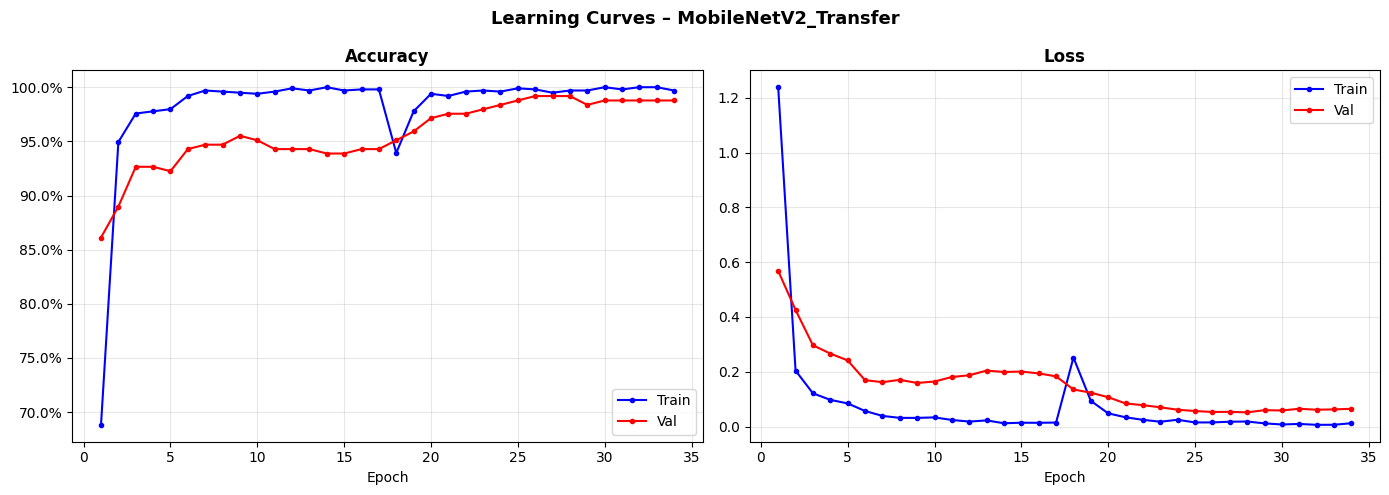

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 282ms/step


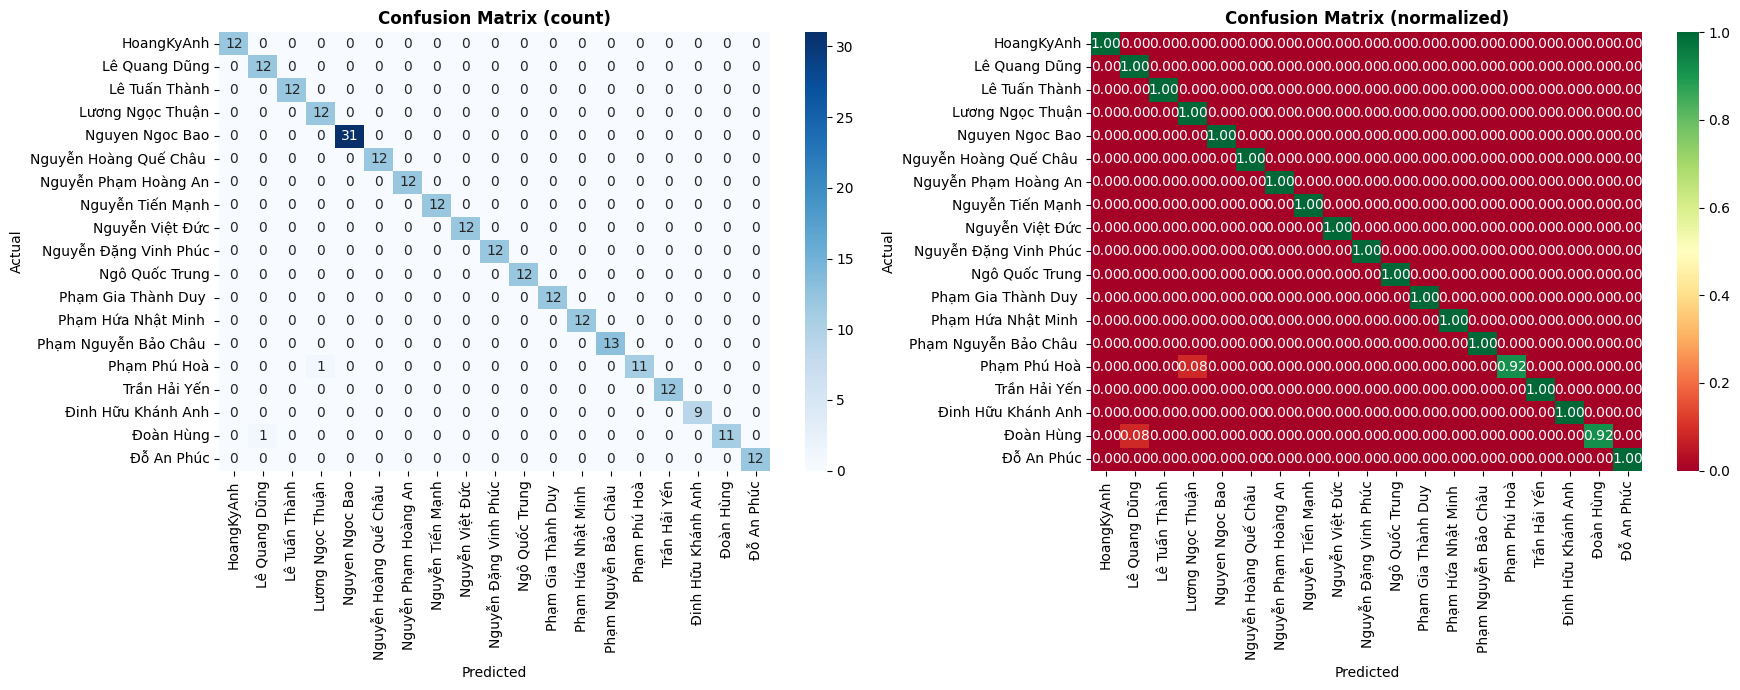

                        precision    recall  f1-score   support

            HoangKyAnh       1.00      1.00      1.00        12
         Lê Quang Dũng       0.92      1.00      0.96        12
         Lê Tuấn Thành       1.00      1.00      1.00        12
      Lương Ngọc Thuận       0.92      1.00      0.96        12
       Nguyen Ngoc Bao       1.00      1.00      1.00        31
Nguyễn Hoàng Quế Châu        1.00      1.00      1.00        12
  Nguyễn Phạm Hoàng An       1.00      1.00      1.00        12
      Nguyễn Tiến Mạnh       1.00      1.00      1.00        12
       Nguyễn Việt Đức       1.00      1.00      1.00        12
 Nguyễn Đặng Vinh Phúc       1.00      1.00      1.00        12
        Ngô Quốc Trung       1.00      1.00      1.00        12
   Phạm Gia Thành Duy        1.00      1.00      1.00        12
   Phạm Hứa Nhật Minh        1.00      1.00      1.00        12
 Phạm Nguyễn Bảo Châu        1.00      1.00      1.00        13
          Phạm Phú Hoà       1.00      

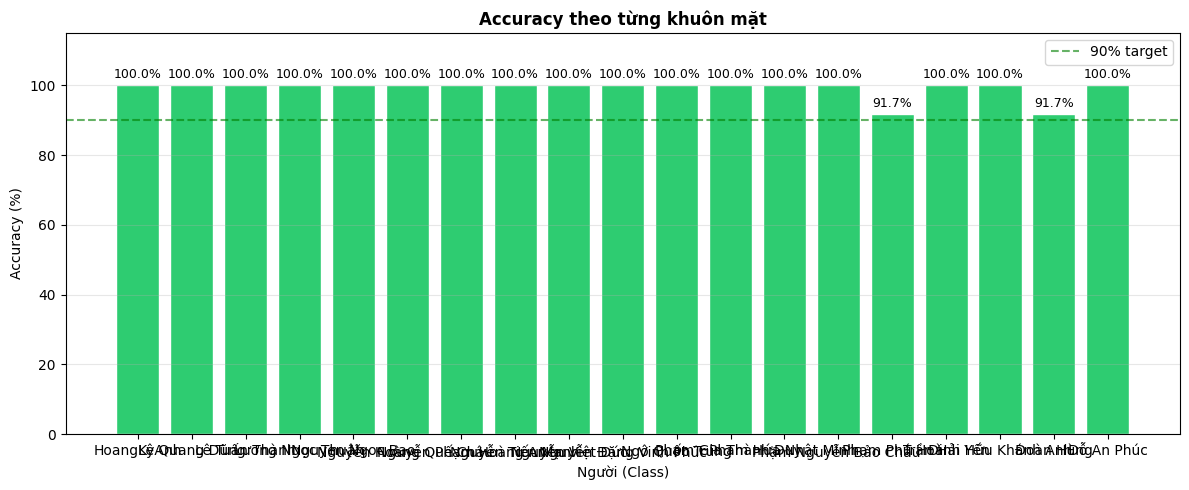

In [ ]:
# Learning Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
ep = range(1, len(final_history.history['accuracy'])+1)
ax1.plot(ep, final_history.history['accuracy'],     'b-o', ms=3, label='Train')
ax1.plot(ep, final_history.history['val_accuracy'], 'r-o', ms=3, label='Val')
ax1.set_title('Accuracy', fontweight='bold'); ax1.set_xlabel('Epoch')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(ep, final_history.history['loss'],     'b-o', ms=3, label='Train')
ax2.plot(ep, final_history.history['val_loss'], 'r-o', ms=3, label='Val')
ax2.set_title('Loss', fontweight='bold'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(alpha=0.3)
plt.suptitle(f'Learning Curves – {model.name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Confusion Matrix + Classification Report
val_gen.reset()
y_pred_prob = model.predict(val_gen, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = val_gen.classes

# Get unique labels actually present in the validation set
unique_labels_in_val = np.unique(y_true)
display_class_names = [class_names[label] for label in unique_labels_in_val]

cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=display_class_names, yticklabels=display_class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (count)', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=display_class_names, yticklabels=display_class_names, ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (normalized)', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y_true, y_pred, target_names=display_class_names, labels=unique_labels_in_val))

# Per-class Accuracy
per_class_acc = cm_norm.diagonal()
colors = ['#2ecc71' if a>=0.9 else '#f39c12' if a>=0.75 else '#e74c3c' for a in per_class_acc]
fig, ax = plt.subplots(figsize=(12,5))
bars = ax.bar(display_class_names, per_class_acc*100, color=colors, edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.axhline(90, color='green', ls='--', alpha=0.6, label='90% target')
ax.set_ylim(0,115); ax.set_xlabel('Người (Class)'); ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy theo từng khuôn mặt', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

def predict_image(img_path):
    img  = Image.open(img_path).convert('RGB').resize(IMG_SIZE)
    arr  = np.expand_dims(np.array(img)/255.0, axis=0)
    prob = model.predict(arr, verbose=0)[0]
    top3 = np.argsort(prob)[::-1][:3]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
    ax1.imshow(img); ax1.axis('off')
    ax1.set_title(f'Dự đoán: {class_names[top3[0]]}\nConfidence: {prob[top3[0]]*100:.1f}%',
                  fontweight='bold', color='green', fontsize=12)
    labels = [f'{class_names[i]}' for i in top3]
    vals   = [prob[i]*100 for i in top3]
    ax2.barh(labels[::-1], vals[::-1], color=['#2ecc71','#3498db','#bdc3c7'])
    ax2.set_xlabel('Confidence (%)'); ax2.set_xlim(0,105)
    ax2.set_title('Top-3 Predictions', fontweight='bold')
    for i,(v,l) in enumerate(zip(vals[::-1],labels[::-1])):
        ax2.text(v+1, i, f'{v:.1f}%', va='center')
    plt.tight_layout(); plt.show()


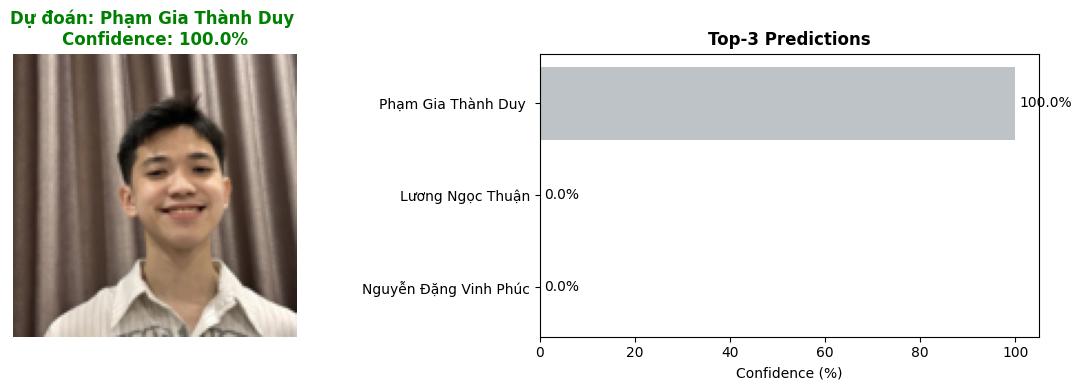

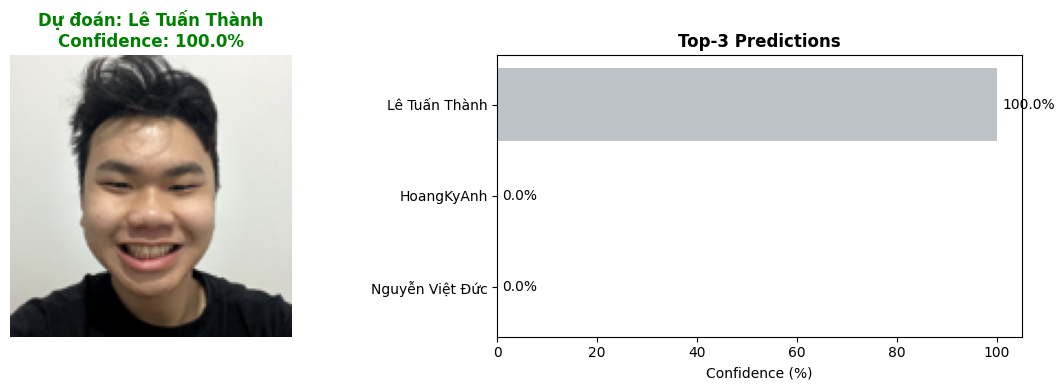

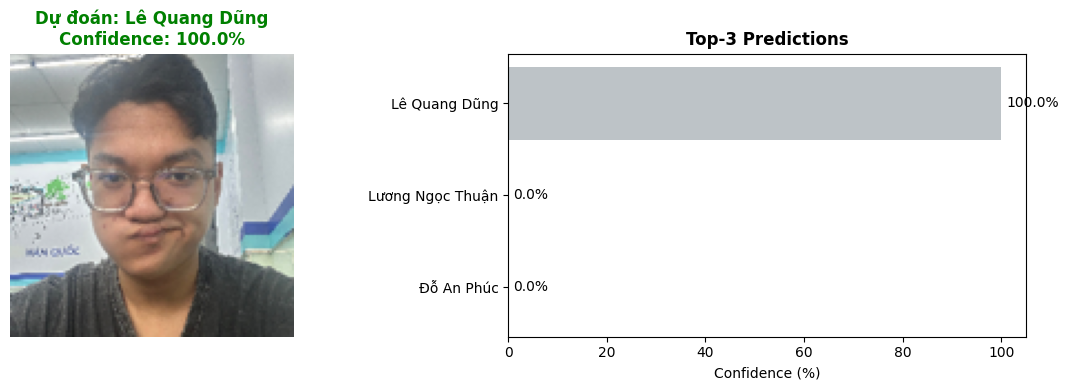

✅ Lưu local : /content/FaceID_MobileNetV2_Transfer.keras
✅ Lưu Drive : /content/drive/MyDrive/FaceID_MobileNetV2_Transfer.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

       KẾT QUẢ CUỐI CÙNG
  Mô hình      : MobileNetV2_Transfer
  Dataset      : Face Recognition – 22 người
  Val Accuracy : 99.18%
  F1 weighted  : 0.9918
  F1 macro     : 0.9912
  Best class   : HoangKyAnh  (100.0%)
  Hard class   : Phạm Hứa Nhật Minh   (91.7%)


In [ ]:
# Demo 3 ảnh ngẫu nhiên từ dataset
sample_paths = []
for cls in classes:
    imgs = [p for p in glob.glob(os.path.join(DATA_DIR, cls, '*'))
            if p.lower().endswith(('.jpg','.jpeg','.png'))]
    if imgs: sample_paths.append(np.random.choice(imgs))

for path in np.random.choice(sample_paths, min(3,len(sample_paths)), replace=False):
    predict_image(path)

# Upload ảnh từ máy để test
from google.colab import files
uploaded_test = files.upload()
for fname in uploaded_test:
    with open(fname, 'wb') as f: f.write(uploaded_test[fname])
    predict_image(fname)

from google.colab import files as colab_files

# Lưu vào Colab
SAVE_LOCAL = f'/content/FaceID_{model.name}.keras'
model.save(SAVE_LOCAL)
print(f'✅ Lưu local : {SAVE_LOCAL}')

# Lưu vào Google Drive
SAVE_DRIVE = f'/content/drive/MyDrive/FaceID_{model.name}.keras'
model.save(SAVE_DRIVE)
print(f'✅ Lưu Drive : {SAVE_DRIVE}')

# Download về máy
colab_files.download(SAVE_LOCAL)

acc = accuracy_score(y_true, y_pred)
f1w = f1_score(y_true, y_pred, average='weighted')
f1m = f1_score(y_true, y_pred, average='macro')

print('=' * 50)
print('       KẾT QUẢ CUỐI CÙNG')
print('=' * 50)
print(f'  Mô hình      : {model.name}')
print(f'  Dataset      : Face Recognition – {NUM_CLASSES} người')
print(f'  Val Accuracy : {acc*100:.2f}%')
print(f'  F1 weighted  : {f1w:.4f}')
print(f'  F1 macro     : {f1m:.4f}')
print(f'  Best class   : {class_names[np.argmax(per_class_acc)]}  ({per_class_acc.max()*100:.1f}%)')
print(f'  Hard class   : {class_names[np.argmin(per_class_acc)]}  ({per_class_acc.min()*100:.1f}%)')
print('=' * 50)